# Phân loại Email Spam
## 7. Đánh giá mô hình

Chúng ta sẽ thực hiện đánh giá toàn diện hai mô hình đã huấn luyện bằng cách tự viết các hàm tính toán chỉ số đánh giá từ đầu (Scratch) và so sánh trực tiếp với Scikit-learn.

### Các chỉ số đánh giá được tính toán từ đầu:
- **Ma trận nhầm lẫn (Confusion Matrix):** TP, FP, TN, FN
- **Accuracy (Độ chính xác tổng thể):** $\frac{\text{TP} + \text{TN}}{\text{TP} + \text{TN} + \text{FP} + \text{FN}}$
- **Precision (Độ chuẩn xác):** $\frac{\text{TP}}{\text{TP} + \text{FP}}$
- **Recall (Độ nhạy / Thu hồi):** $\frac{\text{TP}}{\text{TP} + \text{FN}}$
- **F1-Score (Điểm F1):** $2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$
- **TPR (True Positive Rate - Tỷ lệ dương tính thật):** $\frac{\text{TP}}{\text{TP} + \text{FN}}$
- **FPR (False Positive Rate - Tỷ lệ dương tính giả):** $\frac{\text{FP}}{\text{FP} + \text{TN}}$
- **ROC Curve và AUC (Diện tích dưới đường cong ROC)**


In [9]:
# NaiveBayesClassifierFromScratch phải được định nghĩa trước khi tải
# clf_scratch.pkl, vì thư viện pickle yêu cầu định nghĩa lớp phải hiện diện
# trong namespace chính để thực hiện deserialization thành công.

import numpy as np

class NaiveBayesClassifierFromScratch:
    """
    Bộ phân loại Multinomial Naive Bayes — viết từ đầu.
    Xem notebook 06 để đọc mô tả chi tiết các tham số.
    """

    def __init__(self, alpha=1.0, force_alpha=True,
                 fit_prior=True, class_prior=None):
        self.alpha        = alpha
        self.force_alpha  = force_alpha
        self.fit_prior    = fit_prior
        self.class_prior  = class_prior
        self.classes_          = None
        self.class_priors_     = {}
        self.word_likelihoods_ = {}
        self.vocab_size_       = 0

    def get_params(self, deep=True):
        return {
            "alpha": self.alpha,
            "force_alpha": self.force_alpha,
            "fit_prior": self.fit_prior,
            "class_prior": self.class_prior
        }

    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.classes_    = np.unique(y)
        self.vocab_size_ = n_features
        eff_alpha = self.alpha
        if not self.force_alpha and self.alpha < 1e-10:
            eff_alpha = 1e-10
        if self.class_prior is not None:
            for idx, c in enumerate(self.classes_):
                self.class_priors_[c] = self.class_prior[idx]
        elif not self.fit_prior:
            uniform = 1.0 / len(self.classes_)
            for c in self.classes_:
                self.class_priors_[c] = uniform
        else:
            for c in self.classes_:
                self.class_priors_[c] = np.sum(y == c) / n_samples
        X_arr = X.toarray() if hasattr(X, 'toarray') else np.array(X)
        for c in self.classes_:
            X_c    = X_arr[y == c]
            total  = X_c.sum()
            counts = X_c.sum(axis=0)
            self.word_likelihoods_[c] = (
                (counts + eff_alpha) /
                (total  + eff_alpha * self.vocab_size_)
            )
        return self

    def predict(self, X):
        X_arr = X.toarray() if hasattr(X, 'toarray') else np.array(X)
        preds = []
        for row in X_arr:
            scores = {
                c: np.log(self.class_priors_[c]) +
                   np.sum(row * np.log(self.word_likelihoods_[c]))
                for c in self.classes_
            }
            preds.append(max(scores, key=scores.get))
        return np.array(preds)

    def predict_proba(self, X):
        """Tính xác suất tiên nghiệm qua hàm Softmax ổn định số học."""
        X_arr = X.toarray() if hasattr(X, 'toarray') else np.array(X)
        proba = []
        for row in X_arr:
            log_scores = np.array([
                np.log(self.class_priors_[c]) +
                np.sum(row * np.log(self.word_likelihoods_[c]))
                for c in self.classes_
            ])
            log_scores -= log_scores.max()
            exp_s = np.exp(log_scores)
            proba.append(exp_s / exp_s.sum())
        return np.array(proba)

print('Định nghĩa lớp đã sẵn sàng.')

Định nghĩa lớp đã sẵn sàng.


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os, math, warnings
from sklearn.naive_bayes import MultinomialNB
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

DATA_DIR = r'./data/ready_for_train'

def load_pkl(fname):
    with open(os.path.join(DATA_DIR, fname), 'rb') as f:
        return pickle.load(f)

X_train     = load_pkl('X_train_tfidf.pkl')
X_test      = load_pkl('X_test_tfidf.pkl')
y_train     = load_pkl('y_train.pkl')
y_test      = load_pkl('y_test.pkl')
y_pred_s    = load_pkl('y_pred_scratch.pkl')
y_pred_sk   = load_pkl('y_pred_sklearn.pkl')
clf_scratch = load_pkl('clf_scratch.pkl')
clf_sklearn = load_pkl('clf_sklearn.pkl')
print('Đã tải thành công toàn bộ các kết quả.')

Đã tải thành công toàn bộ các kết quả.


### 7.1 Metric Functions — From Scratch

Binary classification with **positive class = spam**, negative class = ham.

| Symbol | Meaning |
|--------|---------|
| TP | Predicted spam, actually spam |
| FP | Predicted spam, actually ham |
| TN | Predicted ham, actually ham |
| FN | Predicted ham, actually spam |


In [11]:
def compute_confusion_matrix(y_true, y_pred, pos_label='spam', neg_label='ham'):
    tp = int(np.sum((y_true == pos_label) & (y_pred == pos_label)))
    fp = int(np.sum((y_true == neg_label) & (y_pred == pos_label)))
    tn = int(np.sum((y_true == neg_label) & (y_pred == neg_label)))
    fn = int(np.sum((y_true == pos_label) & (y_pred == neg_label)))
    return tp, fp, tn, fn

def compute_metrics(tp, fp, tn, fn):
    accuracy  = (tp + tn) / (tp + fp + tn + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    
    # Tính toán TPR và FPR dạng số thực chuẩn Python
    tpr = recall
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    return float(accuracy), float(precision), float(recall), float(f1), float(tpr), float(fpr)

def compute_roc_curve(y_true, probas, pos_label='spam'):
    y_true_bin = (y_true == pos_label).astype(int)
    desc_indices = np.argsort(probas)[::-1]
    probas = probas[desc_indices]
    y_true_bin = y_true_bin[desc_indices]
    
    tps = np.cumsum(y_true_bin)
    fps = np.cumsum(1 - y_true_bin)
    
    tpr = tps / tps[-1]
    fpr = fps / fps[-1]
    
    fpr = np.r_[0, fpr]
    tpr = np.r_[0, tpr]
    return fpr, tpr

def compute_auc(fpr, tpr):
    return np.trapz(tpr, fpr)

print('Các hàm tính chỉ số đánh giá đã được định nghĩa.')

Các hàm tính chỉ số đánh giá đã được định nghĩa.


### 7.3 Bảng so sánh các chỉ số hiệu năng

In [12]:
tp_s, fp_s, tn_s, fn_s = compute_confusion_matrix(y_test, y_pred_s)
tp_sk, fp_sk, tn_sk, fn_sk = compute_confusion_matrix(y_test, y_pred_sk)

acc_s, prec_s, rec_s, f1_s, tpr_s, fpr_s = compute_metrics(tp_s, fp_s, tn_s, fn_s)
acc_sk, prec_sk, rec_sk, f1_sk, tpr_sk, fpr_sk = compute_metrics(tp_sk, fp_sk, tn_sk, fn_sk)

results_eval = {
    'From Scratch': [tp_s, fp_s, tn_s, fn_s, acc_s*100, prec_s*100, rec_s*100, f1_s*100, tpr_s*100, fpr_s*100],
    'Scikit-learn': [tp_sk, fp_sk, tn_sk, fn_sk, acc_sk*100, prec_sk*100, rec_sk*100, f1_sk*100, tpr_sk*100, fpr_sk*100]
}

summary_df = pd.DataFrame(results_eval, index=['TP', 'FP', 'TN', 'FN', 'Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1 (%)', 'TPR (%)', 'FPR (%)']).T
print(summary_df.round(4).to_string())

                  TP    FP      TN    FN  Accuracy (%)  Precision (%)  Recall (%)  F1 (%)  TPR (%)  FPR (%)
From Scratch  3361.0  52.0  3257.0  63.0        98.292        98.4764       98.16  98.318    98.16   1.5715
Scikit-learn  3361.0  52.0  3257.0  63.0        98.292        98.4764       98.16  98.318    98.16   1.5715


### 7.4 Trực quan hóa Ma trận nhầm lẫn (Confusion Matrix)

Số lượng TP / FP / TN / FN của từng mô hình:
  From Scratch:  TP=3,361  FP=52  TN=3,257  FN=63
  Scikit-learn:  TP=3,361  FP=52  TN=3,257  FN=63


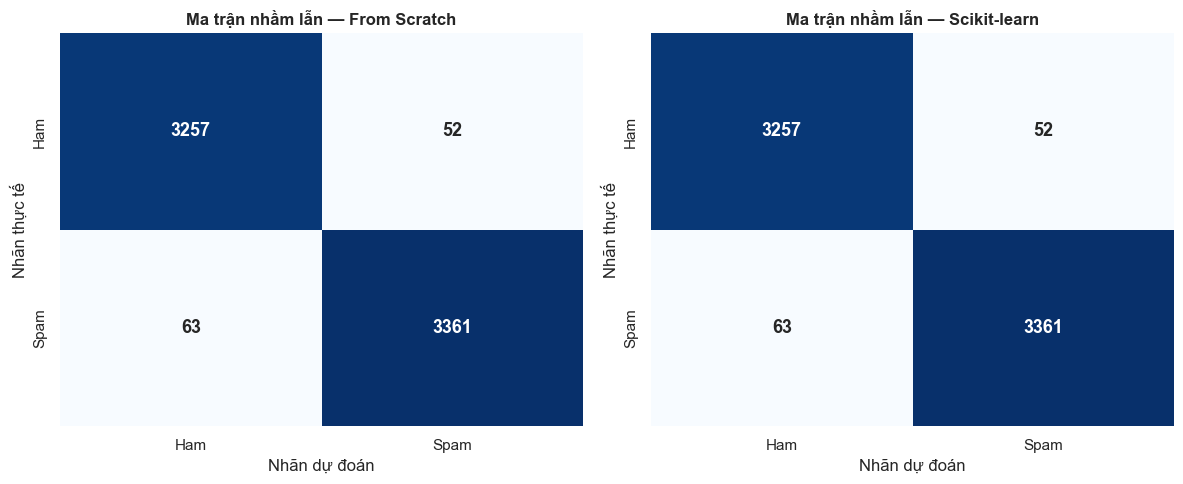

In [13]:
print('Số lượng TP / FP / TN / FN của từng mô hình:')
print(f'  From Scratch:  TP={tp_s:,}  FP={fp_s}  TN={tn_s:,}  FN={fn_s}')
print(f'  Scikit-learn:  TP={tp_sk:,}  FP={fp_sk}  TN={tn_sk:,}  FN={fn_sk}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, matrix, name in zip(
    axes,
    [[[tn_s, fp_s], [fn_s, tp_s]], [[tn_sk, fp_sk], [fn_sk, tp_sk]]],
    ['From Scratch', 'Scikit-learn']
):
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'], ax=ax,
                annot_kws={'fontsize':13, 'fontweight':'bold'})
    ax.set_title(f'Ma trận nhầm lẫn — {name}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Nhãn thực tế')
    ax.set_xlabel('Nhãn dự đoán')

plt.tight_layout()
plt.show()

### 7.4 ROC Curve and AUC — From Scratch

The ROC curve plots **TPR (Recall)** on the Y-axis against **FPR** on the X-axis for each probability threshold.

$$\text{FPR} = \frac{FP}{FP + TN}, \qquad \text{TPR} = \frac{TP}{TP + FN}$$

AUC is computed using the trapezoidal rule:
$$\text{AUC} = \sum_{i=1}^{n-1} (\text{FPR}_{i+1} - \text{FPR}_i) \times \frac{\text{TPR}_i + \text{TPR}_{i+1}}{2}$$


AUC — From Scratch : 0.998312
AUC — Scikit-learn : 0.998312


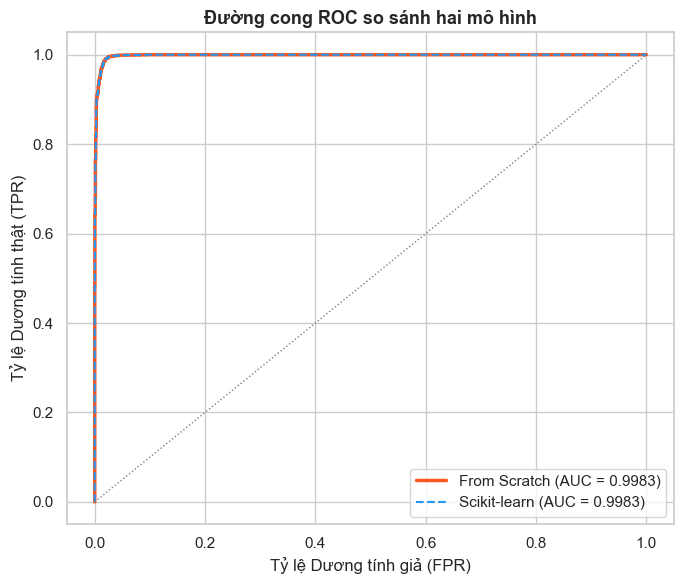

In [14]:
probs_scratch = clf_scratch.predict_proba(X_test)[:, 1]
probs_sklearn = clf_sklearn.predict_proba(X_test)[:, 1]

fpr_s_roc, tpr_s_roc = compute_roc_curve(y_test, probs_scratch)
fpr_sk_roc, tpr_sk_roc = compute_roc_curve(y_test, probs_sklearn)

auc_s  = compute_auc(fpr_s_roc, tpr_s_roc)
auc_sk = compute_auc(fpr_sk_roc, tpr_sk_roc)

print(f'AUC — From Scratch : {auc_s:.6f}')
print(f'AUC — Scikit-learn : {auc_sk:.6f}')

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_s_roc, tpr_s_roc, color='#FF5722', lw=2.5, label=f'From Scratch (AUC = {auc_s:.4f})')
ax.plot(fpr_sk_roc, tpr_sk_roc, color='#2196F3', lw=1.5, ls='--', label=f'Scikit-learn (AUC = {auc_sk:.4f})')
ax.plot([0, 1], [0, 1], color='grey', lw=1, ls=':')

ax.set_title('Đường cong ROC so sánh hai mô hình', fontsize=13, fontweight='bold')
ax.set_xlabel('Tỷ lệ Dương tính giả (FPR)')
ax.set_ylabel('Tỷ lệ Dương tính thật (TPR)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 7.6 Phân tích độ nhạy của tham số alpha

        Accuracy  Precision   Recall       F1      TPR     FPR
alpha                                                         
0.001    98.2920    98.4764  98.1600  98.3180  98.1600  1.5715
0.010    98.2623    98.4755  98.1016  98.2882  98.1016  1.5715
0.050    98.2474    98.4467  98.1016  98.2738  98.1016  1.6017
0.100    98.2177    98.3607  98.1308  98.2456  98.1308  1.6924
0.500    98.2029    98.3036  98.1600  98.2318  98.1600  1.7528
1.000    98.1732    98.2461  98.1600  98.2031  98.1600  1.8132
2.000    98.1435    98.1887  98.1600  98.1744  98.1600  1.8737
5.000    98.1732    98.1898  98.2185  98.2041  98.2185  1.8737
10.000   98.1732    98.1617  98.2477  98.2046  98.2477  1.9039


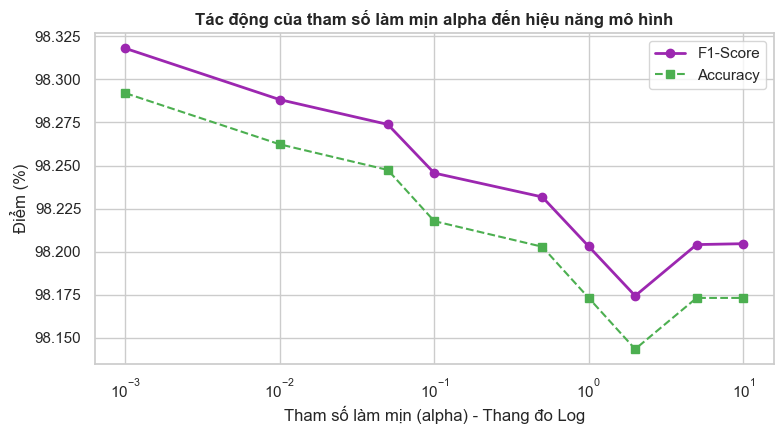

Tham số alpha tối ưu nhất (theo F1): 0.001  ->  F1 = 98.3180%


In [15]:
alphas = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
alpha_results = []

for a in alphas:
    clf_test = NaiveBayesClassifierFromScratch(alpha=a).fit(X_train, y_train)
    preds    = clf_test.predict(X_test)
    tp, fp, tn, fn = compute_confusion_matrix(y_test, preds)
    acc, prec, rec, f1, tpr, fpr = compute_metrics(tp, fp, tn, fn)
    alpha_results.append({
        'alpha': a,
        'Accuracy': acc * 100,
        'Precision': prec * 100,
        'Recall': rec * 100,
        'F1': f1 * 100,
        'TPR': tpr * 100,
        'FPR': fpr * 100
    })

alpha_df = pd.DataFrame(alpha_results).set_index('alpha')
print(alpha_df.round(4))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(alpha_df.index, alpha_df['F1'], marker='o', color='#9C27B0', lw=2, label='F1-Score')
ax.plot(alpha_df.index, alpha_df['Accuracy'], marker='s', color='#4CAF50', lw=1.5, ls='--', label='Accuracy')
ax.set_xscale('log')
ax.set_title('Tác động của tham số làm mịn alpha đến hiệu năng mô hình', fontsize=12, fontweight='bold')
ax.set_xlabel('Tham số làm mịn (alpha) - Thang đo Log')
ax.set_ylabel('Điểm (%)')
ax.legend()
plt.tight_layout()
plt.show()

best_alpha_f1 = alpha_df['F1'].idxmax()
print(f'Tham số alpha tối ưu nhất (theo F1): {best_alpha_f1}  ->  F1 = {alpha_df.loc[best_alpha_f1, "F1"]:.4f}%')

### 7.7 Tóm tắt kết quả đánh giá

In [16]:
print('=' * 60)
print('TỔNG HỢP KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH')
print('=' * 60)
print(f'''
  Từ bộ phân loại From Scratch:
    TP = {tp_s:,}  |  FP = {fp_s}  |  TN = {tn_s:,}  |  FN = {fn_s}
    Accuracy  : {acc_s*100:.4f}%
    Precision : {prec_s*100:.4f}%
    Recall    : {rec_s*100:.4f}%
    F1-Score  : {f1_s*100:.4f}%
    TPR       : {tpr_s*100:.4f}%
    FPR       : {fpr_s*100:.4f}%

  Từ bộ phân loại Scikit-learn:
    TP = {tp_sk:,}  |  FP = {fp_sk}  |  TN = {tn_sk:,}  |  FN = {fn_sk}
    Accuracy  : {acc_sk*100:.4f}%
    Precision : {prec_sk*100:.4f}%
    Recall    : {rec_sk*100:.4f}%
    F1-Score  : {f1_sk*100:.4f}%
    TPR       : {tpr_sk*100:.4f}%
    FPR       : {fpr_sk*100:.4f}%

  AUC — From Scratch : {auc_s:.6f}
  AUC — Scikit-learn : {auc_sk:.6f}
''')
print('=' * 60)

TỔNG HỢP KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH

  Từ bộ phân loại From Scratch:
    TP = 3,361  |  FP = 52  |  TN = 3,257  |  FN = 63
    Accuracy  : 98.2920%
    Precision : 98.4764%
    Recall    : 98.1600%
    F1-Score  : 98.3180%
    TPR       : 98.1600%
    FPR       : 1.5715%

  Từ bộ phân loại Scikit-learn:
    TP = 3,361  |  FP = 52  |  TN = 3,257  |  FN = 63
    Accuracy  : 98.2920%
    Precision : 98.4764%
    Recall    : 98.1600%
    F1-Score  : 98.3180%
    TPR       : 98.1600%
    FPR       : 1.5715%

  AUC — From Scratch : 0.998312
  AUC — Scikit-learn : 0.998312

